<a href="https://colab.research.google.com/github/betulbilhan2/LLM-Augmentation-Fidelity/blob/main/NB06_Embeddings_and_Diversity.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook 06: Embedding Extraction & Diversity/Geometry Analysis

**Goal:**
1. Extract and save BERT embeddings for Original (E0), Back-Translation (E2), and LLM Paraphrase (E3) subsets using the balanced data.
2. Evaluate **Lexical Diversity** via Self-BLEU to verify if the model acts as a "Duplication+" control.
3. Evaluate **Semantic Diversity** via Vendi Score for synthetic pools and merged pools.
4. Evaluate **Class-Conditional Fréchet Distance (FSD)** to verify if emotion geometries are preserved faithfully.
5. Provide UMAP and PCA scatter plots for visual confirmation of cluster distributions in a 2x2 IEEE grid.

In [ ]:
# Install necessary libraries
!pip install -q sentence-transformers pandas numpy scikit-learn umap-learn matplotlib seaborn pyyaml vendi_score nltk Levenshtein

import os
import gc
import json
import yaml
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sentence_transformers import SentenceTransformer
from sklearn.decomposition import PCA
import umap
from scipy import linalg
from vendi_score import vendi
import nltk
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
import Levenshtein

# Download NLTK data for BLEU tokenizer
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

# Mount Google Drive if in Colab
try:
    from google.colab import drive
    drive.mount('/content/drive')
    BASE_DIR = '/content/drive/MyDrive/tr_augmentation_project'
    IN_COLAB = True
except ImportError:
    BASE_DIR = 'C:/Users/btlbi/OneDrive/Masaüstü/TR Veri arttırımı'
    IN_COLAB = False
    print("Colab ortamı bulunamadı, yerel dizin kullanılıyor:", BASE_DIR)

os.makedirs(os.path.join(BASE_DIR, '06_embeddings', 'low'), exist_ok=True)
os.makedirs(os.path.join(BASE_DIR, '06_embeddings', 'normal'), exist_ok=True)
os.makedirs(os.path.join(BASE_DIR, '07_diversity_metrics', 'low'), exist_ok=True)
os.makedirs(os.path.join(BASE_DIR, '07_diversity_metrics', 'normal'), exist_ok=True)
os.makedirs(os.path.join(BASE_DIR, '11_figures'), exist_ok=True)

print("Dizinler hazır.")

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 158.7/158.7 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 37.4 MB/s eta 0:00:00
Mounted at /content/drive
Dizinler hazır.


In [ ]:
# Load Config
config_path = os.path.join(BASE_DIR, 'configs', 'experiment_config.yaml')
with open(config_path, 'r', encoding='utf-8') as f:
    config = yaml.safe_load(f)

DATA_SEEDS = config['seeds']['data_seeds']
RESOURCE_LEVELS = ['low', 'normal']
EMBEDDING_MODEL_NAME = config['quality_filter']['embedding_model']
FSD_EPSILON = float(config['diversity']['fsd_epsilon'])

print(f"Embedding Model: {EMBEDDING_MODEL_NAME}")
print(f"FSD Epsilon: {FSD_EPSILON}")

# Load model
device = 'cuda' if torch.cuda.is_available() else 'cpu'
embedder = SentenceTransformer(EMBEDDING_MODEL_NAME, device=device)
print(f"Model loaded on {device}")

Embedding Model: emrecan/bert-base-turkish-cased-mean-nli-stsb-tr
FSD Epsilon: 1e-06


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/123 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/6.26k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/251k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/498k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Model loaded on cuda


In [ ]:
def calculate_fsd(mu1, sigma1, mu2, sigma2, epsilon=1e-6):
    """Calculates Fréchet Distance with regularization"""
    d = sigma1.shape[0]
    sigma1_reg = sigma1 + epsilon * np.eye(d)
    sigma2_reg = sigma2 + epsilon * np.eye(d)
    diff = mu1 - mu2
    covmean, _ = linalg.sqrtm(sigma1_reg @ sigma2_reg, disp=False)
    if np.iscomplexobj(covmean):
        covmean = covmean.real
    return diff @ diff + np.trace(sigma1_reg + sigma2_reg - 2 * covmean)

def class_conditional_fsd(emb_orig, labels_orig, emb_syn, labels_syn, epsilon=1e-6):
    """Calculates FSD per class, then returns the average"""
    classes = np.unique(labels_orig)
    fsd_scores = []

    for c in classes:
        # Filter embeddings by class
        emb_orig_c = emb_orig[labels_orig == c]
        emb_syn_c = emb_syn[labels_syn == c]

        # If any class is missing or too small (e.g. less than 2 points), skip or handle
        if len(emb_orig_c) < 2 or len(emb_syn_c) < 2:
            continue

        mu1 = np.mean(emb_orig_c, axis=0)
        sigma1 = np.cov(emb_orig_c, rowvar=False)
        mu2 = np.mean(emb_syn_c, axis=0)
        sigma2 = np.cov(emb_syn_c, rowvar=False)

        fsd_c = calculate_fsd(mu1, sigma1, mu2, sigma2, epsilon)
        fsd_scores.append(fsd_c)

    if not fsd_scores:
        return np.nan
    return np.mean(fsd_scores)

In [ ]:
def calculate_corpus_self_bleu(texts, sample_size=100):
    """Calculates Lexical Diversity: Self-BLEU. Lower is more diverse."""
    if len(texts) < 2:
        return 0.0

    smoother = SmoothingFunction().method1
    tokenized_texts = [nltk.word_tokenize(t.lower()) for t in texts]

    # To save time for large sets, we sample
    if len(tokenized_texts) > sample_size:
        indices = np.random.choice(len(tokenized_texts), sample_size, replace=False)
        eval_texts = [tokenized_texts[i] for i in indices]
    else:
        eval_texts = tokenized_texts

    scores = []
    for i, hyp in enumerate(eval_texts):
        # References are all OTHER texts in the eval set
        refs = [eval_texts[j] for j in range(len(eval_texts)) if j != i]
        if refs:
            score = sentence_bleu(refs, hyp, smoothing_function=smoother)
            scores.append(score)

    return np.mean(scores) if scores else 0.0

def calculate_ttr(texts):
    """Type-Token Ratio for Lexical Diversity. Higher is more diverse."""
    words = []
    for t in texts:
        words.extend(nltk.word_tokenize(t.lower()))
    if not words:
        return 0.0
    return len(set(words)) / len(words)

def calculate_paired_metrics(orig_texts, syn_texts):
    """Calculates Paired BLEU and Edit Distance between original and synthetic pairs."""
    smoother = SmoothingFunction().method1
    bleu_scores = []
    edit_distances = []

    for o, s in zip(orig_texts, syn_texts):
        ed = Levenshtein.distance(str(o), str(s))
        edit_distances.append(ed)

        ref = [nltk.word_tokenize(str(o).lower())]
        hyp = nltk.word_tokenize(str(s).lower())
        if len(hyp) > 0 and len(ref[0]) > 0:
            b_score = sentence_bleu(ref, hyp, smoothing_function=smoother)
        else:
            b_score = 0.0
        bleu_scores.append(b_score)

    return np.mean(bleu_scores), np.mean(edit_distances)

In [ ]:
# Store metrics
metrics_records = []

for level in RESOURCE_LEVELS:
    print(f"\n--- Processing {level.upper()} ---")

    for seed in DATA_SEEDS:
        # Load Original
        orig_path = os.path.join(BASE_DIR, '01_splits', level, f'seed_{seed}', 'train_seed.csv')
        df_orig = pd.read_csv(orig_path)

        # Load Balanced Synthetic
        bt_path = os.path.join(BASE_DIR, '05_balanced', level, 'backtranslation', f'seed_{seed}', 'pool_balanced.csv')
        llm_path = os.path.join(BASE_DIR, '05_balanced', level, 'llm_paraphrase', f'seed_{seed}', 'pool_balanced.csv')

        # Skip if balanced pool doesn't exist (edge case)
        if not os.path.exists(bt_path) or not os.path.exists(llm_path):
            print(f"Skipping Seed {seed} for {level} (Missing balanced files)")
            continue

        df_bt = pd.read_csv(bt_path)
        df_llm = pd.read_csv(llm_path)

        label_col = 'label' if 'label' in df_orig.columns else 'sentiment'

        # Extract Texts and Labels
        t_orig, l_orig = df_orig['text'].astype(str).tolist(), df_orig[label_col].values

        # BT text column handling (in case it's named 'augmented_text')
        bt_col = 'augmented_text' if 'augmented_text' in df_bt.columns else 'text'
        t_bt, l_bt = df_bt[bt_col].astype(str).tolist(), df_bt[label_col].values

        llm_col = 'augmented_text' if 'augmented_text' in df_llm.columns else 'text'
        t_llm, l_llm = df_llm[llm_col].astype(str).tolist(), df_llm[label_col].values

        # 1. Embedding Extraction
        emb_orig = embedder.encode(t_orig, convert_to_numpy=True, show_progress_bar=False)
        emb_bt = embedder.encode(t_bt, convert_to_numpy=True, show_progress_bar=False)
        emb_llm = embedder.encode(t_llm, convert_to_numpy=True, show_progress_bar=False)

        # Save Embeddings to Disk
        np.save(os.path.join(BASE_DIR, '06_embeddings', level, f'original_seed{seed}.npy'), emb_orig)
        np.save(os.path.join(BASE_DIR, '06_embeddings', level, f'bt_seed{seed}.npy'), emb_bt)
        np.save(os.path.join(BASE_DIR, '06_embeddings', level, f'llm_seed{seed}.npy'), emb_llm)

        # 2. Vendi Score (Semantic Diversity)
        # Define a cosine similarity kernel for the embeddings
        def cosine_kernel(x, y):
            x_norm = x / (np.linalg.norm(x, axis=-1, keepdims=True) + 1e-9)
            y_norm = y / (np.linalg.norm(y, axis=-1, keepdims=True) + 1e-9)
            return x_norm @ y_norm.T

        # Synthetic only
        vendi_bt = vendi.score(emb_bt, k=cosine_kernel)
        vendi_llm = vendi.score(emb_llm, k=cosine_kernel)

        # Merged pools
        emb_merged_bt = np.vstack([emb_orig, emb_bt])
        emb_merged_llm = np.vstack([emb_orig, emb_llm])
        vendi_merged_bt = vendi.score(emb_merged_bt, k=cosine_kernel)
        vendi_merged_llm = vendi.score(emb_merged_llm, k=cosine_kernel)

        # 3. FSD (Class-Conditional)
        fsd_bt = class_conditional_fsd(emb_orig, l_orig, emb_bt, l_bt, epsilon=FSD_EPSILON)
        fsd_llm = class_conditional_fsd(emb_orig, l_orig, emb_llm, l_llm, epsilon=FSD_EPSILON)

        # 4. Lexical Diversity (Self-BLEU & TTR)
        # Using a fixed seed for random sampling inside self-bleu
        np.random.seed(42)
        sbleu_bt = calculate_corpus_self_bleu(t_bt)
        sbleu_llm = calculate_corpus_self_bleu(t_llm)

        ttr_bt = calculate_ttr(t_bt)
        ttr_llm = calculate_ttr(t_llm)

        # 5. Paired Lexical Diversity (Paired-BLEU & Edit Distance)
        p_bleu_bt, ed_bt = calculate_paired_metrics(t_orig, t_bt)
        p_bleu_llm, ed_llm = calculate_paired_metrics(t_orig, t_llm)

        metrics_records.append({
            'level': level,
            'seed': seed,
            'vendi_bt_only': vendi_bt,
            'vendi_llm_only': vendi_llm,
            'vendi_merged_bt': vendi_merged_bt,
            'vendi_merged_llm': vendi_merged_llm,
            'fsd_class_conditional_bt': fsd_bt,
            'fsd_class_conditional_llm': fsd_llm,
            'self_bleu_bt': sbleu_bt,
            'self_bleu_llm': sbleu_llm,
            'ttr_bt': ttr_bt,
            'ttr_llm': ttr_llm,
            'paired_bleu_bt': p_bleu_bt,
            'paired_bleu_llm': p_bleu_llm,
            'edit_distance_bt': ed_bt,
            'edit_distance_llm': ed_llm
        })

    print(f"Metrics computed for {level}.")

df_metrics = pd.DataFrame(metrics_records)
for level in RESOURCE_LEVELS:
    df_level = df_metrics[df_metrics['level'] == level]
    out_csv = os.path.join(BASE_DIR, '07_diversity_metrics', level, 'all_metrics_summary.csv')
    df_level.to_csv(out_csv, index=False)

print("All metrics saved successfully.")


--- Processing LOW ---


/tmp/ipykernel_1341/52248526.py:7: DeprecationWarning: The `disp` argument is deprecated and will be removed in SciPy 1.18.0.
  covmean, _ = linalg.sqrtm(sigma1_reg @ sigma2_reg, disp=False)
/tmp/ipykernel_1341/52248526.py:7: DeprecationWarning: The `disp` argument is deprecated and will be removed in SciPy 1.18.0.
  covmean, _ = linalg.sqrtm(sigma1_reg @ sigma2_reg, disp=False)
/tmp/ipykernel_1341/52248526.py:7: DeprecationWarning: The `disp` argument is deprecated and will be removed in SciPy 1.18.0.
  covmean, _ = linalg.sqrtm(sigma1_reg @ sigma2_reg, disp=False)
/tmp/ipykernel_1341/52248526.py:7: DeprecationWarning: The `disp` argument is deprecated and will be removed in SciPy 1.18.0.
  covmean, _ = linalg.sqrtm(sigma1_reg @ sigma2_reg, disp=False)
/tmp/ipykernel_1341/52248526.py:7: DeprecationWarning: The `disp` argument is deprecated and will be removed in SciPy 1.18.0.
  covmean, _ = linalg.sqrtm(sigma1_reg @ sigma2_reg, disp=False)
/tmp/ipykernel_1341/52248526.py:7: Deprecatio

Metrics computed for low.

--- Processing NORMAL ---


/tmp/ipykernel_1341/52248526.py:7: DeprecationWarning: The `disp` argument is deprecated and will be removed in SciPy 1.18.0.
  covmean, _ = linalg.sqrtm(sigma1_reg @ sigma2_reg, disp=False)
/tmp/ipykernel_1341/52248526.py:7: DeprecationWarning: The `disp` argument is deprecated and will be removed in SciPy 1.18.0.
  covmean, _ = linalg.sqrtm(sigma1_reg @ sigma2_reg, disp=False)
/tmp/ipykernel_1341/52248526.py:7: DeprecationWarning: The `disp` argument is deprecated and will be removed in SciPy 1.18.0.
  covmean, _ = linalg.sqrtm(sigma1_reg @ sigma2_reg, disp=False)
/tmp/ipykernel_1341/52248526.py:7: DeprecationWarning: The `disp` argument is deprecated and will be removed in SciPy 1.18.0.
  covmean, _ = linalg.sqrtm(sigma1_reg @ sigma2_reg, disp=False)
/tmp/ipykernel_1341/52248526.py:7: DeprecationWarning: The `disp` argument is deprecated and will be removed in SciPy 1.18.0.
  covmean, _ = linalg.sqrtm(sigma1_reg @ sigma2_reg, disp=False)
/tmp/ipykernel_1341/52248526.py:7: Deprecatio

Metrics computed for normal.
All metrics saved successfully.


In [ ]:
# Display Averages
summary = df_metrics.groupby('level').mean(numeric_only=True)
import IPython.display as display
display.display(summary)

,seed,vendi_bt_only,vendi_llm_only,vendi_merged_bt,vendi_merged_llm,fsd_class_conditional_bt,fsd_class_conditional_llm,self_bleu_bt,self_bleu_llm,ttr_bt,ttr_llm,paired_bleu_bt,paired_bleu_llm,edit_distance_bt,edit_distance_llm
level,,,,,,,,,,,,,,,
low,4.5,18.756819,18.269172,25.578142,24.733805,167.930024,149.635291,0.036798,0.032986,0.616855,0.643790,0.035937,0.012078,156.111918,197.160221
normal,4.5,77.409217,73.000064,89.171471,85.838319,99.283420,87.108622,0.063009,0.054973,0.419711,0.420891,0.013238,0.008752,176.112992,211.269070


In [ ]:
import sys
sys.path.append(os.path.join(BASE_DIR))
try:
    from utils.plotting import set_ieee_style, COLORS, LINESTYLES
    set_ieee_style()
except Exception as e:
    print("Warning: Could not load utils.plotting, using seaborn defaults.", e)
    import seaborn as sns
    sns.set_theme(style='whitegrid')
    COLORS = {
        "original": "#333333", "duplication_control": "#7f7f7f",
        "backtranslation": "#1f77b4", "llm_paraphrase": "#d62728",
    }

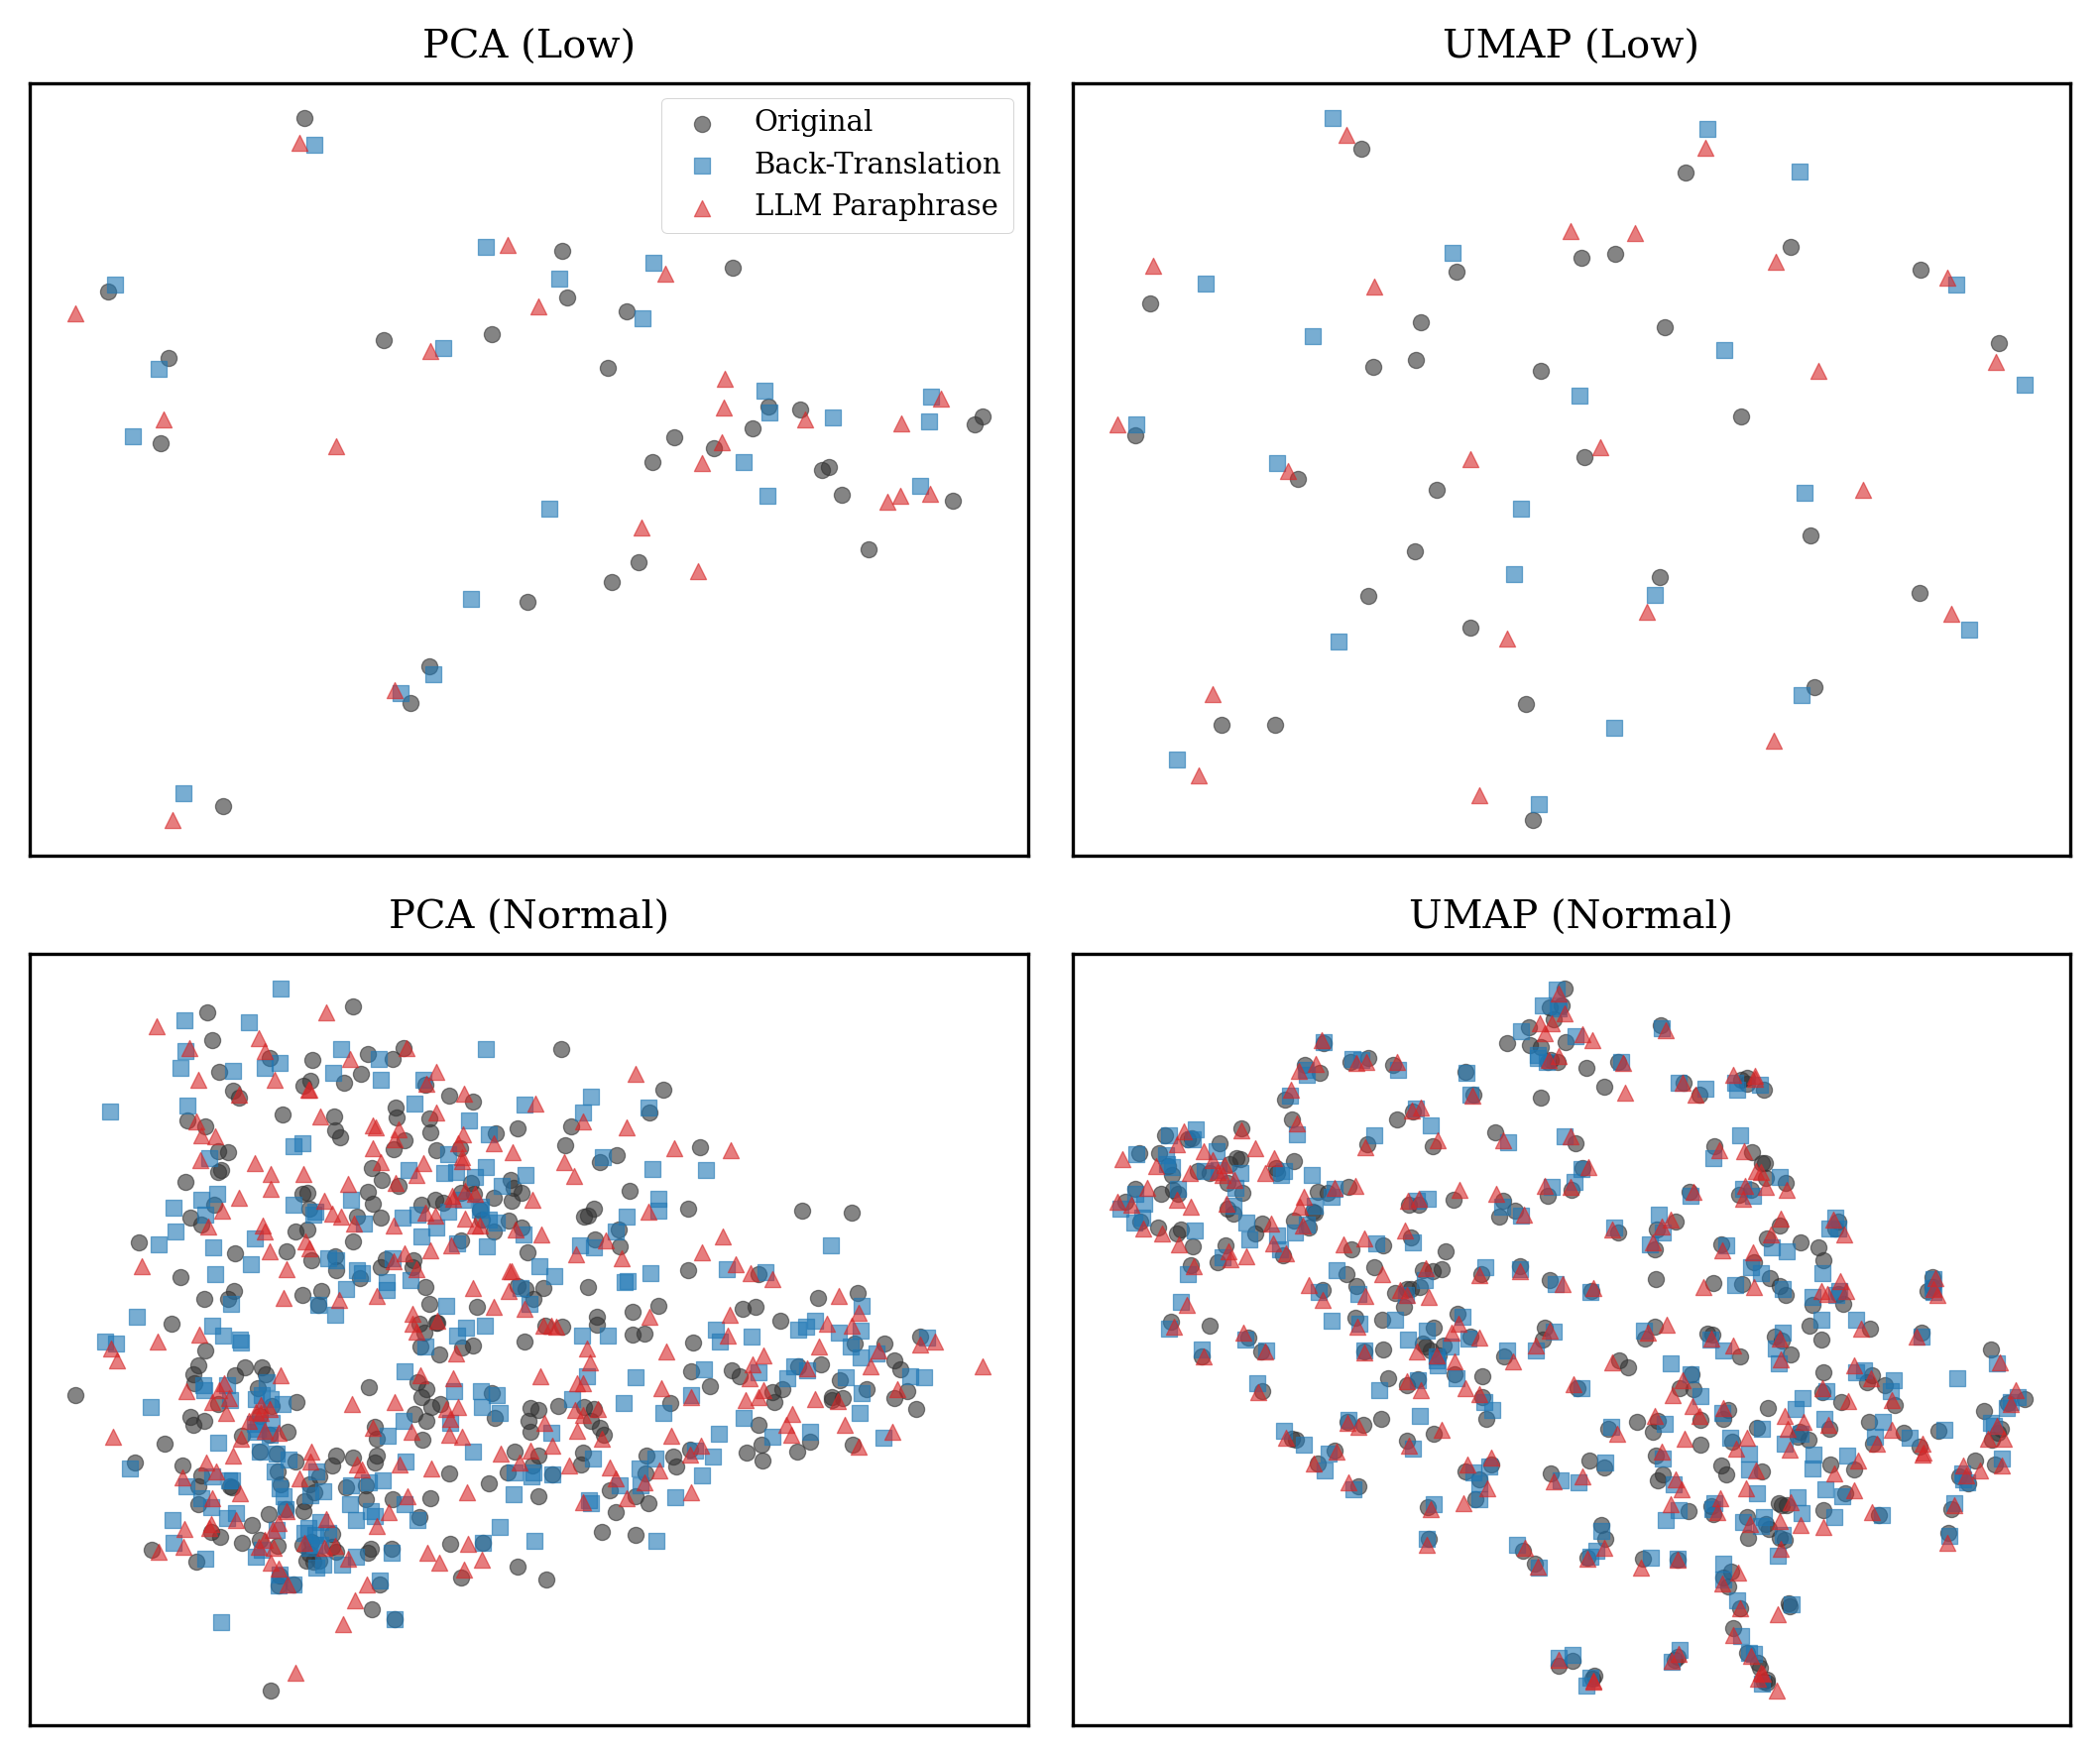

IEEE formatted figure saved to: /content/drive/MyDrive/tr_augmentation_project/11_figures/embeddings_pca_umap_grid.pdf


In [ ]:
# Visualization 2x2 Grid for PCA and UMAP (using Seed 0 as representative)

fig, axes = plt.subplots(2, 2, figsize=(7.16, 6)) # IEEE 2-column width approx
seed_to_plot = 0

for i, level in enumerate(RESOURCE_LEVELS):
    # Load embeddings for seed 0
    emb_orig = np.load(os.path.join(BASE_DIR, '06_embeddings', level, f'original_seed{seed_to_plot}.npy'))
    emb_bt = np.load(os.path.join(BASE_DIR, '06_embeddings', level, f'bt_seed{seed_to_plot}.npy'))
    emb_llm = np.load(os.path.join(BASE_DIR, '06_embeddings', level, f'llm_seed{seed_to_plot}.npy'))

    # Labels for plotting
    labels_orig = ['Original'] * len(emb_orig)
    labels_bt = ['Back-Translation'] * len(emb_bt)
    labels_llm = ['LLM Paraphrase'] * len(emb_llm)

    X_all = np.vstack([emb_orig, emb_bt, emb_llm])
    y_all = np.array(labels_orig + labels_bt + labels_llm)

    # PCA
    pca = PCA(n_components=2, random_state=42)
    X_pca = pca.fit_transform(X_all)

    # UMAP
    import warnings
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        reducer = umap.UMAP(n_components=2, random_state=42, n_neighbors=15, min_dist=0.1)
        X_umap = reducer.fit_transform(X_all)

    # Plot PCA (Col 0)
    ax_pca = axes[i, 0]
    sns.scatterplot(x=X_pca[y_all=='Original', 0], y=X_pca[y_all=='Original', 1],
                    ax=ax_pca, color=COLORS['original'], label='Original', alpha=0.6, s=15, edgecolor=None)
    sns.scatterplot(x=X_pca[y_all=='Back-Translation', 0], y=X_pca[y_all=='Back-Translation', 1],
                    ax=ax_pca, color=COLORS['backtranslation'], label='Back-Translation', alpha=0.6, s=15, marker='s', edgecolor=None)
    sns.scatterplot(x=X_pca[y_all=='LLM Paraphrase', 0], y=X_pca[y_all=='LLM Paraphrase', 1],
                    ax=ax_pca, color=COLORS['llm_paraphrase'], label='LLM Paraphrase', alpha=0.6, s=15, marker='^', edgecolor=None)
    ax_pca.set_title(f'PCA ({level.capitalize()})')
    ax_pca.set_xticks([])
    ax_pca.set_yticks([])
    if i == 0: ax_pca.legend(loc='best', fontsize=7)
    else: ax_pca.get_legend().remove()

    # Plot UMAP (Col 1)
    ax_umap = axes[i, 1]
    sns.scatterplot(x=X_umap[y_all=='Original', 0], y=X_umap[y_all=='Original', 1],
                    ax=ax_umap, color=COLORS['original'], label='Original', alpha=0.6, s=15, edgecolor=None)
    sns.scatterplot(x=X_umap[y_all=='Back-Translation', 0], y=X_umap[y_all=='Back-Translation', 1],
                    ax=ax_umap, color=COLORS['backtranslation'], label='Back-Translation', alpha=0.6, s=15, marker='s', edgecolor=None)
    sns.scatterplot(x=X_umap[y_all=='LLM Paraphrase', 0], y=X_umap[y_all=='LLM Paraphrase', 1],
                    ax=ax_umap, color=COLORS['llm_paraphrase'], label='LLM Paraphrase', alpha=0.6, s=15, marker='^', edgecolor=None)
    ax_umap.set_title(f'UMAP ({level.capitalize()})')
    ax_umap.set_xticks([])
    ax_umap.set_yticks([])
    if ax_umap.get_legend():
        ax_umap.get_legend().remove()

plt.tight_layout()
fig_path = os.path.join(BASE_DIR, '11_figures', 'embeddings_pca_umap_grid.pdf')
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"IEEE formatted figure saved to: {fig_path}")